# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU3.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.

## Část 1: Číselná spirála

Vytvořte čtvercovou matici o lichém počtu řádků a sloupců, která bude obsahovat čísla od 1 do $n^2$ tak, aby číslo 1 bylo uprostřed matice a číselná řada postupně narůstala po spirále proti směru hodinových ručiček.
- udělejte to pomocí NumPy přiřazování sliců do pole,
- výstup musí být stejný jako u primitivní funkce `integer_spiral` níže,
- vyplňujte matici po „kruzích“ okolo středu,
    - každý kruh je tvořen 4 částmi (hrana bez jednoho rohu),
    - využijte možnosti přiřazování sliců do pole a indexace s krokem `-1`,
    - použijte `np.arange` pro vytvoření řady čísel, kterou budete ukládat do hrany,
- pomozte si také okrajem z nul, který nakonec oříznete.

**Výsledná funkce bude mít tedy pouze jednu smyčku, ve které do pole vstoupíte pouze 4x (jednou za každou hranu).**

**Na závěr porovnejte rychlost vaší funkce s `integer_spiral` níže pomocí `%timeit` a různých velikostí výsledných matic (např. 101, 1001, 10001).**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# naplnění matice spirálou čísel
def integer_spiral(n):
    # abychom nemuseli řešit okraj = kontrolovat jestli jsme mimo matici
    # vytvoříme matici o velikosti n+2 x n+2
    # a vyplníme pouze středovou část
    A = np.zeros((n + 2, n + 2))

    pos_row = n//2 + 1  # počáteční pozice: střed matice
    pos_col = n//2 + 1

    i = 1  # číslo, které se bude vkládat do matice

    A[pos_row, pos_col] = i  # vložíme číslo do středu matice
    i += 1
    pos_col += 1  # posuneme se na první volné místo

    while i <= n**2:  # dokud nejsme na konci matice
        A[pos_row, pos_col] = i  # vložíme číslo na aktuální pozici
        i += 1  # zvýšíme číslo, které se má vložit
        if A[pos_row - 1, pos_col] != 0 and A[pos_row, pos_col + 1] == 0:
            pos_col += 1  # posuneme se doprava
        elif A[pos_row, pos_col - 1] != 0:
            pos_row -= 1  # posuneme se nahoru
        elif A[pos_row + 1, pos_col] != 0:
            pos_col -= 1  # posuneme se doleva
        else:
            pos_row += 1  # posuneme se dolů

    return A[1:-1, 1:-1]  # ořízneme nulový okraj


In [3]:
A = integer_spiral(7)
print(A)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [4]:
def integer_spiral_numpy(n):
    A = np.zeros((n,n))
    S = A

    a = n * n + 1
    while True:
        if n == 1:
            S[0, 0] = 1
            break

        n -= 1

        S[-1, 1:] = np.arange(a-n, a)
        a -= n

        S[1:, 0] = np.arange(a-n, a)
        a -= n
        a -= 1

        S[0, :-1] = np.arange(a, a-n, -1)
        a -= n

        S[:-1, -1] = np.arange(a, a-n, -1)
        a -= n
        a +=1

        n -= 1
        S = S[1:-1, 1:-1]

    return A 

In [5]:
# TODO otestujte rychlost obou implementací
%timeit integer_spiral(101)
%timeit integer_spiral_numpy(101)

%timeit integer_spiral(1001)
%timeit integer_spiral_numpy(1001)

%timeit integer_spiral(10001)
%timeit integer_spiral_numpy(10001)

2.46 ms ± 35.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
127 μs ± 1.47 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
247 ms ± 1.34 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.71 ms ± 14 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
25.4 s ± 150 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
168 ms ± 772 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Část 2: Mandelbrotova množina
Vizualizujte Mandelbrotovu množinu na intervalu $[-2, 1] \times [-1.5, 1.5]$ pomocí `imshow`. Výsledek by měl vypadat jako na následujícím obrázku.
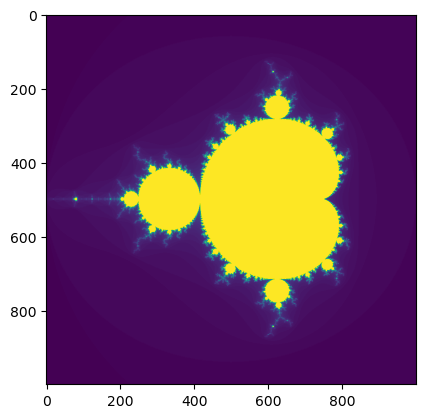

**Co je Mandelbrotova množina?**

Mandelbrotova množina je množina komplexních čísel $c$, pro které platí, že posloupnost $z_{i+1} = z_i^2 + c$ s $z_0 = 0$ nekonverguje do nekonečna (tj. $|z_i|$ zůstává omezené).

**Co tedy udělat?**
- vytvořte matici $n\times n$ komplexních čísel $c$ na intervalu $[-2, 1] \times [-1.5, 1.5]$ (pomocí `np.mgrid` nebo `np.meshgrid`),
    - využijte výhody vektorizace a toho, že NumPy umí násobit komplexní čísla,
- stanovte si počet iterací $k$, pro které budete testovat, zda posloupnost nedivergovala,
    - divergování posloupnosti poznáme tak, že $|z_i| > 2$ pro nějaké $i$,
- proveďte $k$ iterací posloupnosti $z_{i+1} = z_i^2 + c$ a zjistěte, ve které iteraci nastalo $|z_i| > 2$ (jakmile to nastane jednou, bude to platit pro všechna další $i$),
    - použijte pomocnou matici `divergence_matrix`, která bude mít stejný rozměr jako `c` a bude obsahovat počet iterací, kdy $|z_i| < 2$ pro každé $c$,
- vytvořte obrázek pomocí `imshow` z `divergence_matrix`.

In [6]:
def mandelbrot_set(x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    # vytvoření mřížky komplexních čísel c
    x = np.linspace(x_min, x_max, n)
    y = np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    c = X + 1j * Y

    # počáteční hodnoty
    z = np.zeros_like(c, dtype=np.complex128)
    divergence_matrix = np.zeros(c.shape, dtype=int)
    mask = np.ones(c.shape, dtype=bool)

    for i in range(k):
        z[mask] = z[mask]**2 + c[mask]

        diverged = np.abs(z) > 2
        divergence_matrix[mask & diverged] = i
        mask = mask & (~diverged)

    divergence_matrix[mask] = k

    return divergence_matrix

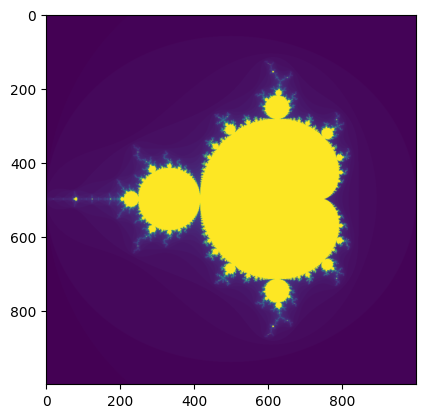

In [7]:
n = 1000
k = 100

divergence_matrix = mandelbrot_set(n=n, k=k)
plt.imshow(divergence_matrix)

## Bonusové úkoly
1. Vykreslete také Juliovu množinu (viz https://en.wikipedia.org/wiki/Julia_set).
2. Použijte váš kód pro číselnou spirálu a vytvořte obrázek prvočíselné spirály (viz https://en.wikipedia.org/wiki/Ulam_spiral).

In [8]:
def julia_set(x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    # vytvoření mřížky komplexních čísel c
    x = np.linspace(x_min, x_max, n)
    y = np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    z = X + 1j * Y

    # počáteční hodnoty
    #c = np.zeros_like(z, dtype=np.complex128)
    c =  -0.5125 + 0.5213j
    divergence_matrix = np.zeros(z.shape, dtype=int)
    mask = np.ones(z.shape, dtype=bool)

    for i in range(k):
        z[mask] = z[mask]**2 + c

        diverged = np.abs(z) > 2
        divergence_matrix[mask & diverged] = i
        mask = mask & (~diverged)

    divergence_matrix[mask] = k

    return divergence_matrix

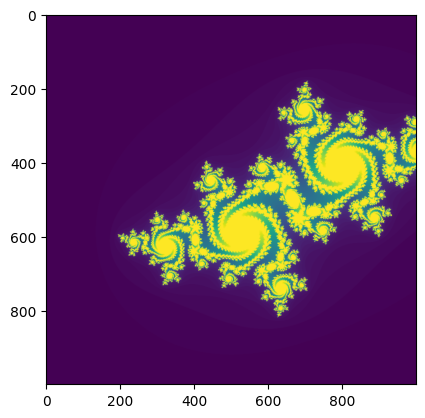

In [9]:
n = 1000
k = 100

divergence_matrix = julia_set(n=n, k=k)
plt.imshow(divergence_matrix)

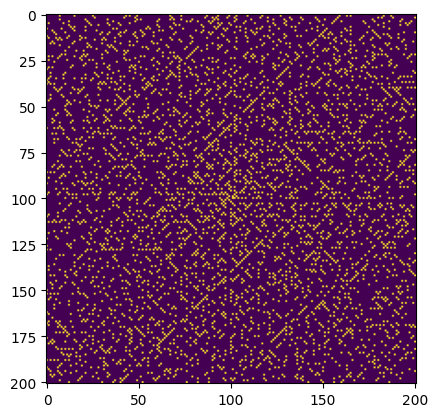

In [10]:
def is_prime(n):
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

def ulam_spiral(n):
    grid = integer_spiral_numpy(n)

    for i in range(n):
        for j in range(n):
            grid[i, j] = 1 if is_prime(grid[i, j]) else 0

    return grid

plt.imshow(ulam_spiral(201))
